## Program Structure

1. Import Libraries  
2. Load Dataset  
3. Feature Engineering (avg_demage)  
4. Define X and y  
5. Train-Test Split  
6. Scaling  
7. Visualization (Before vs After)  
8. Model Training  
9. Evaluation  

In [106]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [107]:
df = pd.read_csv("/content/wows_ship_stats.csv")

In [108]:
df.head(5)

,Ship,Tier,Class,Nation,Players,Battles,Base XP,Damage,Frags,Win rate,Capture,Defence,Spotting,Potential,Aircraft,Survival rate
0,Patrie,11,BB,France,9092,337170,1388,125865,0.936,0.512,2.13,4.74,19358,1809099,5.60,0.426
1,Hannover,11,BB,Germany,16503,319701,1150,86471,0.633,0.485,1.81,4.16,20080,1930510,6.42,0.240
2,Satsuma,11,BB,Japan,40417,1562549,1246,112667,0.809,0.499,1.32,3.21,17402,1730502,4.15,0.469
3,Devastation,11,BB,U.K.,5660,140172,1323,127807,0.766,0.499,1.98,4.78,20776,1896948,4.71,0.499
4,Maine,11,BB,U.S.A.,10744,352970,1344,114812,0.890,0.513,2.32,4.11,22194,2078203,7.70,0.445


In [109]:
df.isnull().sum()

,0
Ship,0
Tier,0
Class,0
Nation,0
Players,0
Battles,0
Base XP,0
Damage,0
Frags,0
Win rate,0


In [110]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 925 entries, 0 to 924
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Ship           925 non-null    object 
 1   Tier           925 non-null    int64  
 2   Class          925 non-null    object 
 3   Nation         925 non-null    object 
 4   Players        925 non-null    int64  
 5   Battles        925 non-null    int64  
 6   Base XP        925 non-null    int64  
 7   Damage         925 non-null    int64  
 8   Frags          925 non-null    float64
 9   Win rate       925 non-null    float64
 10  Capture        925 non-null    float64
 11  Defence        925 non-null    float64
 12  Spotting       925 non-null    int64  
 13  Potential      925 non-null    int64  
 14  Aircraft       925 non-null    float64
 15  Survival rate  925 non-null    float64
dtypes: float64(6), int64(7), object(3)
memory usage: 115.8+ KB


In [111]:
df.describe()

,Tier,Players,Battles,Base XP,Damage,Frags,Win rate,Capture,Defence,Spotting,Potential,Aircraft,Survival rate
count,925.000000,925.000000,9.250000e+02,925.000000,925.000000,925.000000,925.000000,925.000000,925.000000,925.000000,9.250000e+02,925.000000,925.000000
mean,7.339459,36561.282162,1.045073e+06,975.094054,49264.187027,0.804107,0.516699,11.309276,8.213459,22148.997838,7.128088e+05,3.689265,0.371503
std,2.342301,48974.272885,1.767742e+06,223.569790,23863.731582,0.384416,0.032881,11.585104,6.976746,17686.419281,4.358737e+05,3.296722,0.116186
min,1.000000,1.000000,1.000000e+00,468.000000,9487.000000,0.384000,0.000000,0.000000,0.000000,143.000000,3.611100e+04,0.000000,0.000000
25%,6.000000,7385.000000,9.483000e+04,822.000000,31164.000000,0.614000,0.499000,3.590000,5.130000,11462.000000,3.723430e+05,1.320000,0.296000
50%,8.000000,17844.000000,3.460050e+05,1008.000000,44287.000000,0.716000,0.513000,5.990000,7.050000,17756.000000,6.162530e+05,3.370000,0.349000
75%,9.000000,47185.000000,1.109821e+06,1139.000000,62895.000000,0.860000,0.531000,15.160000,9.280000,26158.000000,1.026331e+06,5.120000,0.415000
max,11.000000,302858.000000,1.832192e+07,1451.000000,145521.000000,4.906000,0.720000,48.160000,102.370000,120030.000000,2.329626e+06,27.880000,0.830000


In [112]:
df.sample(5)

,Ship,Tier,Class,Nation,Players,Battles,Base XP,Damage,Frags,Win rate,Capture,Defence,Spotting,Potential,Aircraft,Survival rate
309,Langley,4,CV,U.S.A.,140697,2419183,529,29120,0.763,0.501,0.64,15.59,13337,141654,3.15,0.579
16,Schlieffen,10,BB,Germany,51693,2023337,1049,66650,0.616,0.490,2.98,5.11,19777,1493223,5.49,0.162
859,Mutsuki (< 01.12.2016),6,DD,Japan,44827,2928327,746,17641,0.494,0.481,24.71,2.59,19404,49982,0.45,0.302
722,AL Shimakaze,10,DD,Japan,3761,205744,1109,43533,0.734,0.511,36.37,4.21,59826,523525,1.52,0.370
584,Dupleix,6,CA,France,8771,38705,820,34307,0.719,0.529,5.09,7.37,9244,570067,1.45,0.232


In [113]:
df['avg_demage'] = df['Damage'] / df['Battles']


## Train test split

In [114]:
X = df[['Players', 'Battles']]
y = df['avg_demage']

In [115]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=0)

print(x_test.shape,y_test.shape)

(185, 2) (185,)


In [116]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit the scaler to the train set ,it will learn parameter
scaler.fit(x_train)

#Transform train and test sets

x_train_scaled = scaler.transform(x_train)
x_test_scaled = scaler.transform(x_test)

scaler.mean_


array([  35259.37972973, 1011876.8527027 ])

In [117]:
x_train_scaled

array([[-0.13158762, -0.48157758],
       [ 0.64661901,  0.37400013],
       [-0.7382974 , -0.61714041],
       ...,
       [-0.32296817, -0.38750052],
       [ 0.22627601, -0.2050435 ],
       [-0.3103266 , -0.57283942]])

In [118]:
x_train_scaled = pd.DataFrame(x_train_scaled, columns=X.columns)
x_test_scaled = pd.DataFrame(x_test_scaled, columns=X.columns)

print(x_train_scaled)

      Players   Battles
0   -0.131588 -0.481578
1    0.646619  0.374000
2   -0.738297 -0.617140
3    0.319052  1.927005
4   -0.172448  0.744608
..        ...       ...
735 -0.082028 -0.340695
736 -0.064823 -0.117641
737 -0.322968 -0.387501
738  0.226276 -0.205043
739 -0.310327 -0.572839

[740 rows x 2 columns]


In [119]:
np.round(x_train_scaled.describe(),1)

,Players,Battles
count,740.0,740.0
mean,0.0,-0.0
std,1.0,1.0
min,-0.8,-0.6
25%,-0.6,-0.6
50%,-0.4,-0.4
75%,0.2,0.1
max,5.7,6.9


## Effect Of Scaling

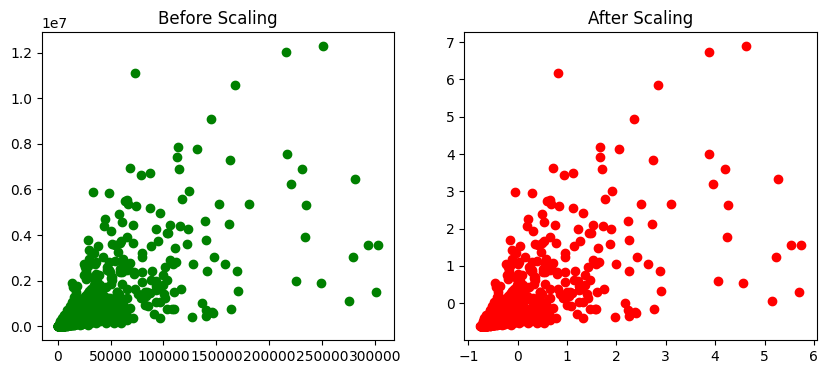

In [120]:
fig,(ax1,ax2) = plt.subplots(ncols=2,figsize=(10,4))

ax1.scatter(x_train['Players'],x_train['Battles'], color='green')
ax1.set_title("Before Scaling")

ax2.scatter(x_train_scaled['Players'],x_train_scaled['Battles'], color='red')
ax2.set_title("After Scaling")

plt.show()

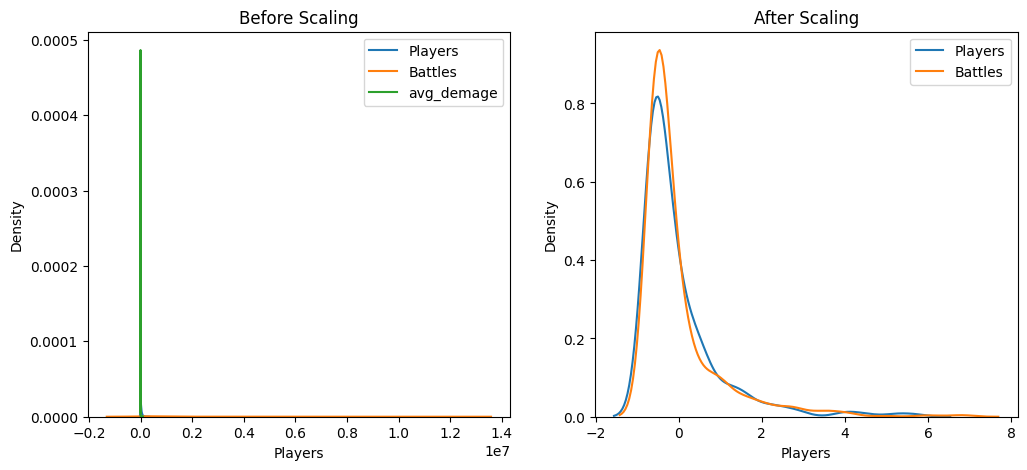

In [121]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12,5))

# Before Scaling
ax1.set_title("Before Scaling")
sns.kdeplot(x_train['Players'], ax=ax1, label='Players')
sns.kdeplot(x_train['Battles'], ax=ax1, label='Battles')
sns.kdeplot(y_train, ax=ax1, label='avg_demage')
ax1.legend()

# After Scaling
ax2.set_title("After Scaling")
sns.kdeplot(x_train_scaled['Players'], ax=ax2, label='Players')
sns.kdeplot(x_train_scaled['Battles'], ax=ax2, label='Battles')
ax2.legend()

plt.show()

## Comparison of Distribution

<Axes: title={'center': 'After Scaling'}, xlabel='Players', ylabel='Density'>

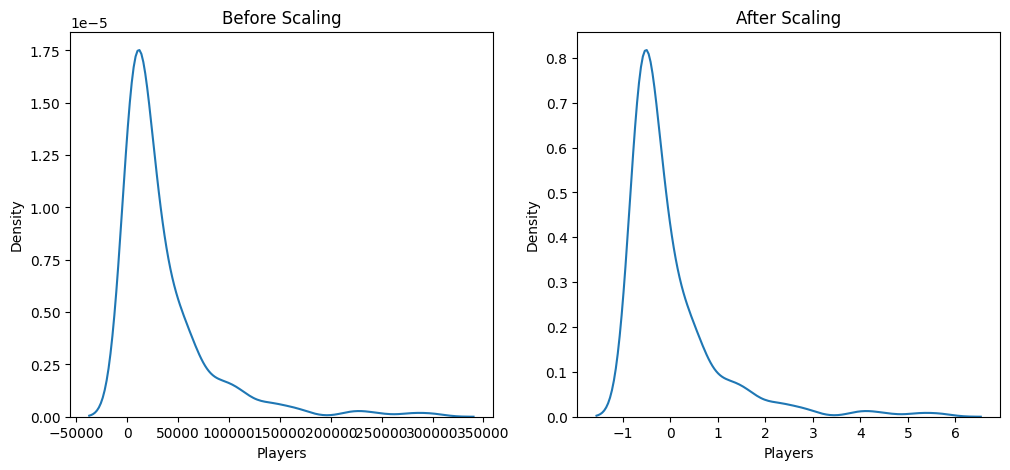

In [122]:
fig,(ax1,ax2) = plt.subplots(ncols=2,figsize=(12,5))
ax1.set_title("Before Scaling")
sns.kdeplot(x_train['Players'],ax = ax1)



ax2.set_title("After Scaling")
sns.kdeplot(x_train_scaled['Players'],ax = ax2)


<Axes: title={'center': 'After Scaling'}, xlabel='Battles', ylabel='Density'>

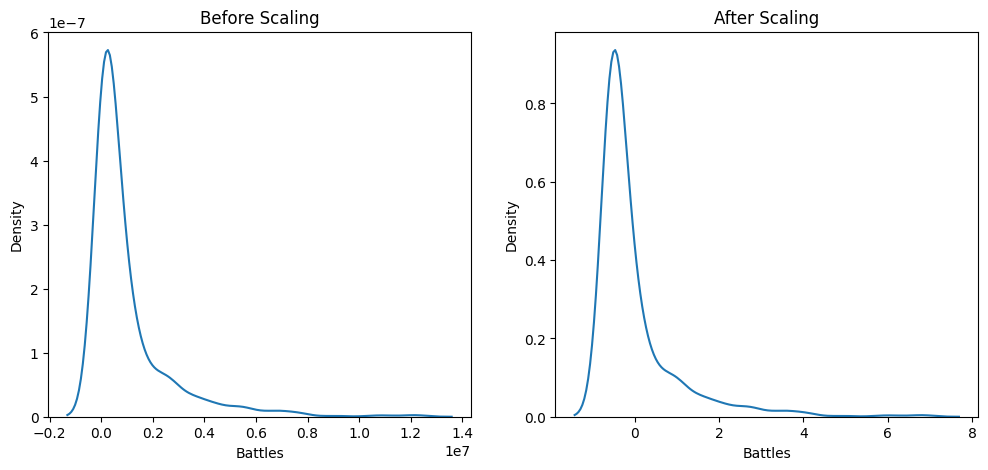

In [123]:
fig,(ax1,ax2) = plt.subplots(ncols=2,figsize=(12,5))
ax1.set_title("Before Scaling")
sns.kdeplot(x_train['Battles'],ax = ax1)

ax2.set_title("After Scaling")
sns.kdeplot(x_train_scaled['Battles'],ax = ax2)

## Why Scaling Is Important



In [124]:
from sklearn.linear_model import LinearRegression


In [125]:
lr = LinearRegression()
lr_scaled = LinearRegression()


In [126]:
lr.fit(x_train,y_train)
lr_scaled.fit(x_train_scaled,y_train)

LinearRegression()

In [127]:
y_pred = lr.predict(x_test)
y_pred_scaled = lr.predict(x_test_scaled)

In [128]:
from sklearn.metrics import mean_squared_error,r2_score


In [129]:
print("MSE (Normal):", mean_squared_error(y_test, y_pred))
print("R2 (Normal):", r2_score(y_test, y_pred))

print("MSE (Scaled):", mean_squared_error(y_test, y_pred_scaled))
print("R2 (Scaled):", r2_score(y_test, y_pred_scaled))

MSE (Normal): 72827.10544092784
R2 (Normal): -0.2454571480206098
MSE (Scaled): 82945.92584206129
R2 (Scaled): -0.41850476706062123


# Conclusion:
- Scaling normalizes feature values
- Improves model performance (in some cases)
- Important for distance-based algorithms